# 📘 Exploratory Data Analysis (EDA) for Disease Testing Dataset

In [1]:
# Import libraries and dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

# Load the dataset
df = pd.read_csv('../backend/Training/Data/Testing.csv')


# Basic Dataset Overview

In [10]:
print("Dataset Shape:", df.shape)

Dataset Shape: (41, 133)


In [11]:
print("\nFirst 5 rows:\n", df.head())


First 5 rows:
    itching  skin_rash  nodal_skin_eruptions  continuous_sneezing  shivering  \
0        1          1                     1                    0          0   
1        0          0                     0                    1          1   
2        0          0                     0                    0          0   
3        1          0                     0                    0          0   
4        1          1                     0                    0          0   

   chills  joint_pain  stomach_pain  acidity  ulcers_on_tongue  \
0       0           0             0        0                 0   
1       1           0             0        0                 0   
2       0           0             1        1                 1   
3       0           0             0        0                 0   
4       0           0             1        0                 0   

   muscle_wasting  vomiting  burning_micturition  spotting_ urination  \
0               0         0            

In [15]:
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Columns: 133 entries, itching to prognosis
dtypes: int64(132), object(1)
memory usage: 42.7+ KB
None


In [16]:
print("\nMissing Values:\n", df.isnull().sum().sum())


Missing Values:
 0


In [17]:
print("\nUnique values in 'prognosis':", df['prognosis'].nunique())


Unique values in 'prognosis': 41


In [18]:
print("Disease Categories:\n", df['prognosis'].unique())

Disease Categories:
 ['Fungal infection' 'Allergy' 'GERD' 'Chronic cholestasis' 'Drug Reaction'
 'Peptic ulcer diseae' 'AIDS' 'Diabetes ' 'Gastroenteritis'
 'Bronchial Asthma' 'Hypertension ' 'Migraine' 'Cervical spondylosis'
 'Paralysis (brain hemorrhage)' 'Jaundice' 'Malaria' 'Chicken pox'
 'Dengue' 'Typhoid' 'hepatitis A' 'Hepatitis B' 'Hepatitis C'
 'Hepatitis D' 'Hepatitis E' 'Alcoholic hepatitis' 'Tuberculosis'
 'Common Cold' 'Pneumonia' 'Dimorphic hemmorhoids(piles)' 'Heart attack'
 'Varicose veins' 'Hypothyroidism' 'Hyperthyroidism' 'Hypoglycemia'
 'Osteoarthristis' 'Arthritis' '(vertigo) Paroymsal  Positional Vertigo'
 'Acne' 'Urinary tract infection' 'Psoriasis' 'Impetigo']


In [9]:
# Statistical Summary
print("\nStatistical Summary of Symptoms:\n", df.describe().T)


Statistical Summary of Symptoms:
                       count      mean       std  min  25%  50%  75%  max
itching                41.0  0.146341  0.357839  0.0  0.0  0.0  0.0  1.0
skin_rash              41.0  0.170732  0.380949  0.0  0.0  0.0  0.0  1.0
nodal_skin_eruptions   41.0  0.024390  0.156174  0.0  0.0  0.0  0.0  1.0
continuous_sneezing    41.0  0.048780  0.218085  0.0  0.0  0.0  0.0  1.0
shivering              41.0  0.024390  0.156174  0.0  0.0  0.0  0.0  1.0
...                     ...       ...       ...  ...  ...  ...  ...  ...
small_dents_in_nails   41.0  0.024390  0.156174  0.0  0.0  0.0  0.0  1.0
inflammatory_nails     41.0  0.024390  0.156174  0.0  0.0  0.0  0.0  1.0
blister                41.0  0.024390  0.156174  0.0  0.0  0.0  0.0  1.0
red_sore_around_nose   41.0  0.024390  0.156174  0.0  0.0  0.0  0.0  1.0
yellow_crust_ooze      41.0  0.024390  0.156174  0.0  0.0  0.0  0.0  1.0

[132 rows x 8 columns]


C:\Users\hp\AppData\Local\Temp\ipykernel_3048\2454008206.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='prognosis', order=df['prognosis'].value_counts().index, palette="viridis")


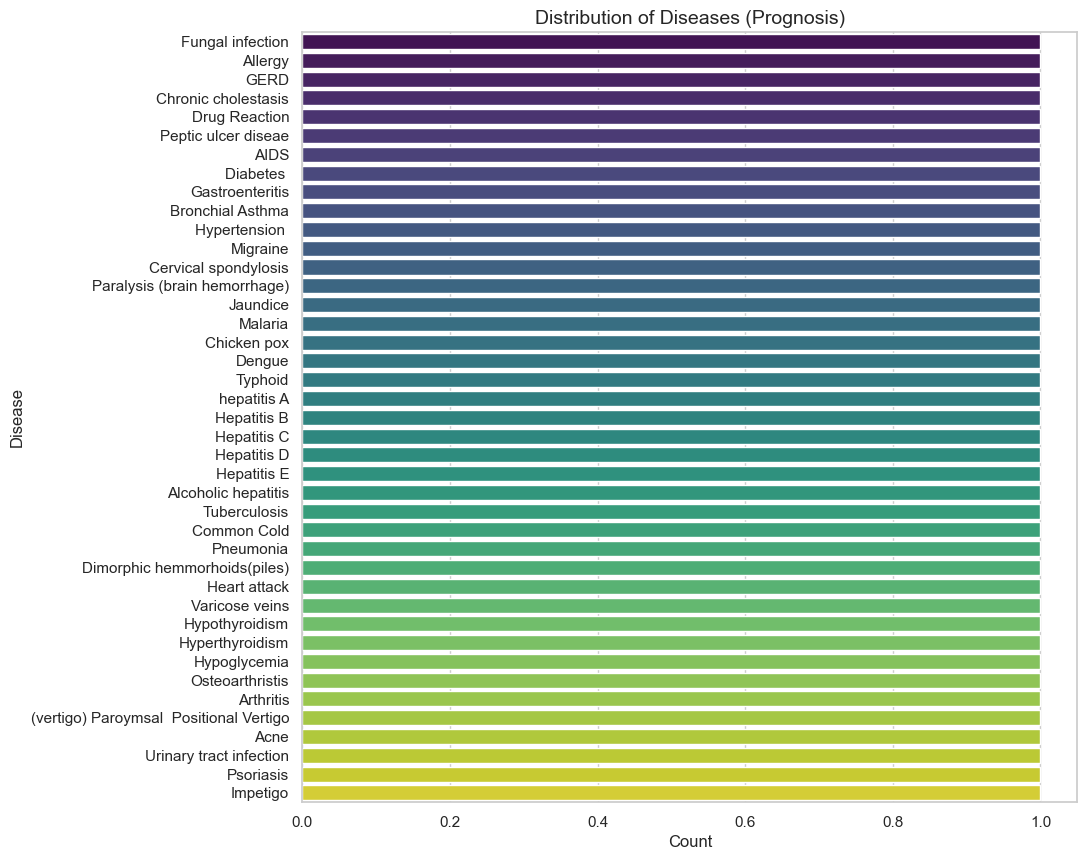

In [5]:
# Target Variable Analysis
plt.figure(figsize=(10,10))
sns.countplot(data=df, y='prognosis', order=df['prognosis'].value_counts().index, palette="viridis")
plt.title("Distribution of Diseases (Prognosis)", fontsize=14)
plt.xlabel("Count")
plt.ylabel("Disease")
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_3048\2424563709.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=symptom_sum.values[:20], y=symptom_sum.index[:20], palette="mako")


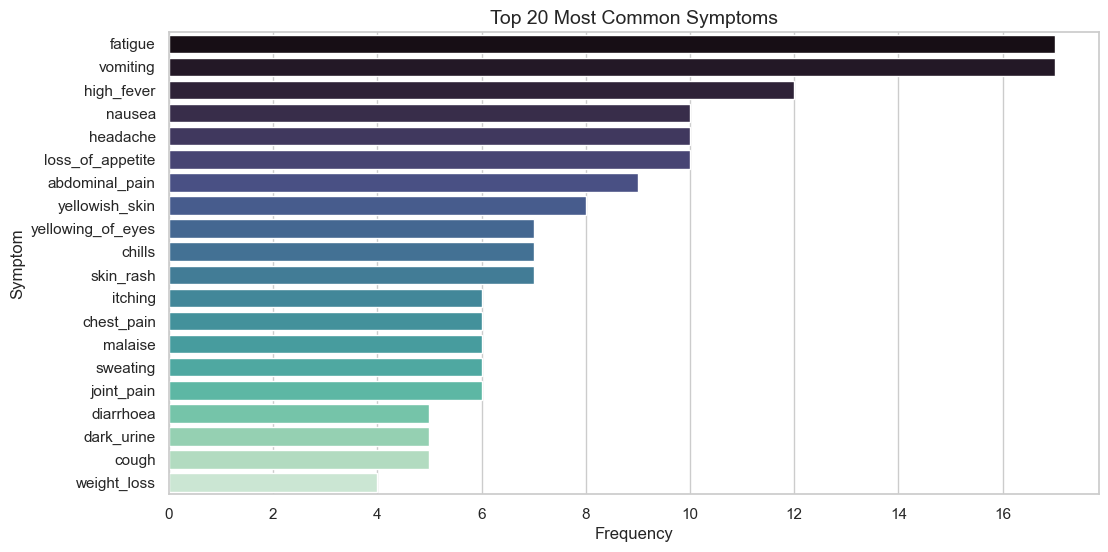

In [6]:
# Symptom Frequency Analysis
symptom_cols = df.columns[:-1]  # exclude prognosis
symptom_sum = df[symptom_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=symptom_sum.values[:20], y=symptom_sum.index[:20], palette="mako")
plt.title("Top 20 Most Common Symptoms", fontsize=14)
plt.xlabel("Frequency")
plt.ylabel("Symptom")
plt.show()

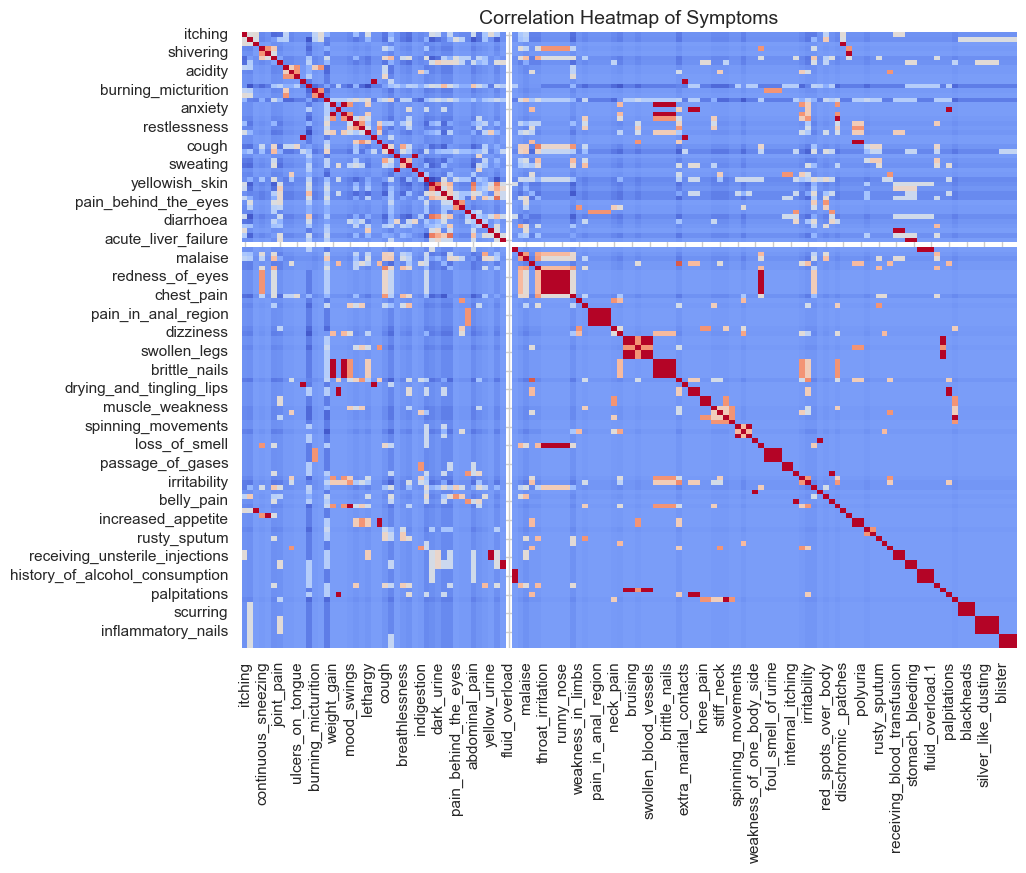

In [7]:
# Correlation Analysis
plt.figure(figsize=(10,8))
corr = df[symptom_cols].corr()
sns.heatmap(corr, cmap="coolwarm", cbar=False)
plt.title("Correlation Heatmap of Symptoms", fontsize=14)
plt.show()

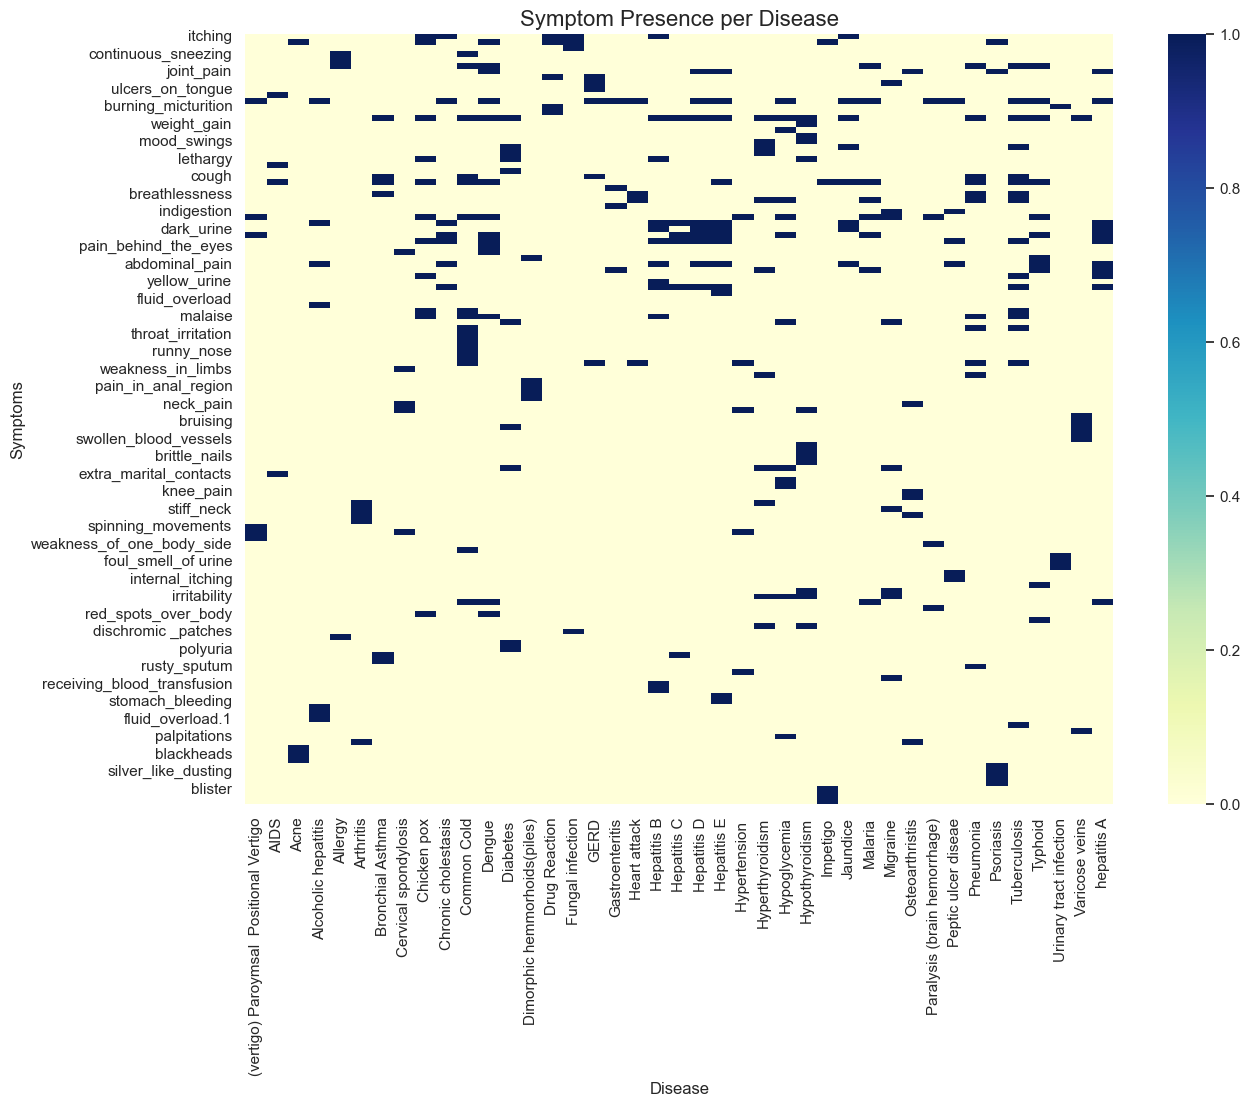

In [8]:
# Disease-Symptom Heatmap
plt.figure(figsize=(14,10))
disease_symptom = df.groupby("prognosis")[symptom_cols].sum()
sns.heatmap(disease_symptom.T, cmap="YlGnBu", cbar=True)
plt.title("Symptom Presence per Disease", fontsize=16)
plt.xlabel("Disease")
plt.ylabel("Symptoms")
plt.show()